# 00. Обзор: данные и постановка

**Тема:** Стресс-тестирование эконометрических моделей волатильности (GARCH) на синтетических данных, созданных GAN.

**Два исследовательских вопроса:**
1. **TSTR.** Можно ли заменить реальные данные синтетическими (от TimeGAN) при обучении GARCH без существенной потери качества прогноза?
2. **Augmentation.** Помогает ли расширение реального ряда синтетическим продолжением (от TimeGAN) улучшить прогноз GARCH?

**Данные:** S&P 500 (`^GSPC`), дневные log-доходности, 2010-01-05 — 2024-12-31.  
**Сплит:** train = 2010–2019 (2515 наблюдений), test = 2020–2024 (1258). Test намеренно содержит COVID-крах, восстановление и инфляционный 2022 — стресс-полигон.

**Эксперименты (4 ветки):**

| Ветка | Источник train | GAN | Augmentation |
|---|---|---|---|
| **B1** | real 2010–2019 | — | — |
| **B2-TimeGAN** | synth от TimeGAN(real train) | TimeGAN | нет |
| **B2-CTGAN** | synth от CTGAN(real train) | CTGAN (контраст) | нет |
| **B3** | real train + synth TimeGAN | TimeGAN | да |

Во всех ветках: GARCH(1,1)-t, параметры **фиксируются** после обучения, walk-forward один шаг вперёд на test.

In [1]:
import sys, json
from pathlib import Path
import pandas as pd

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT))
from src import data as dm

prices, returns = dm.load_or_download()
train, test = dm.train_test_split(returns)

print(f"prices: {len(prices)} строк, {prices.index.min().date()} -> {prices.index.max().date()}")
print(f"train : {len(train)}  ({train.index.min().date()} -> {train.index.max().date()})")
print(f"test  : {len(test)}  ({test.index.min().date()} -> {test.index.max().date()})")

prices: 4100 строк, 2010-01-04 -> 2026-04-22
train : 2515  (2010-01-05 -> 2019-12-31)
test  : 1258  (2020-01-02 -> 2024-12-31)


In [2]:
desc = pd.DataFrame({
    "train (2010-2019), %": (train * 100).describe(),
    "test  (2020-2024), %": (test  * 100).describe(),
}).round(4)
desc

,"train (2010-2019), %","test (2020-2024), %"
count,2515.0000,1258.0000
mean,0.0417,0.0476
std,0.9317,1.3496
min,-6.8958,-12.7652
25%,-0.3272,-0.5319
50%,0.0593,0.0895
75%,0.5029,0.7256
max,4.8403,8.9683


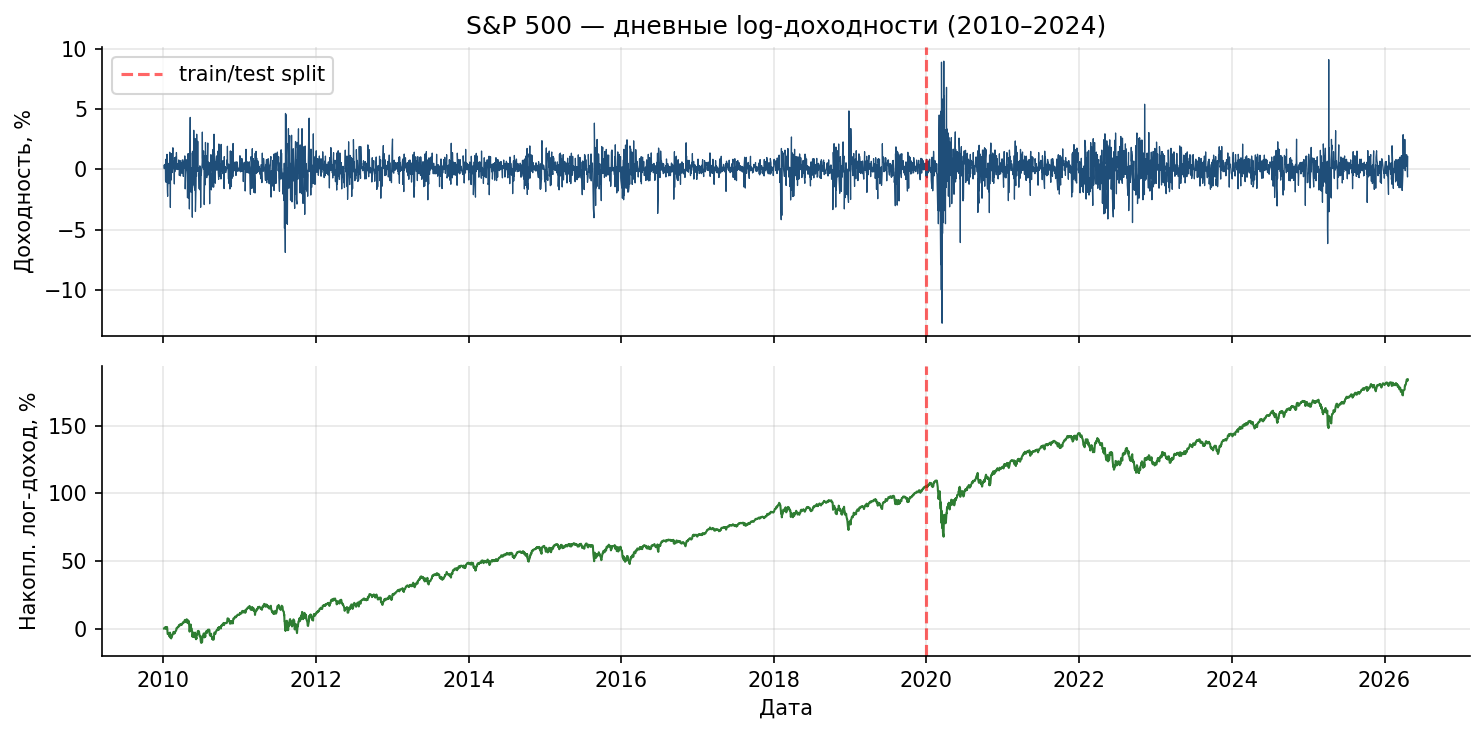

In [3]:
from IPython.display import Image
Image(filename="artifacts/figures/01_returns_overview.png")